[bold red]*****TOP N COUNTRIES (HIGHEST NUMBER OF ATTACKS *****[/bold red]


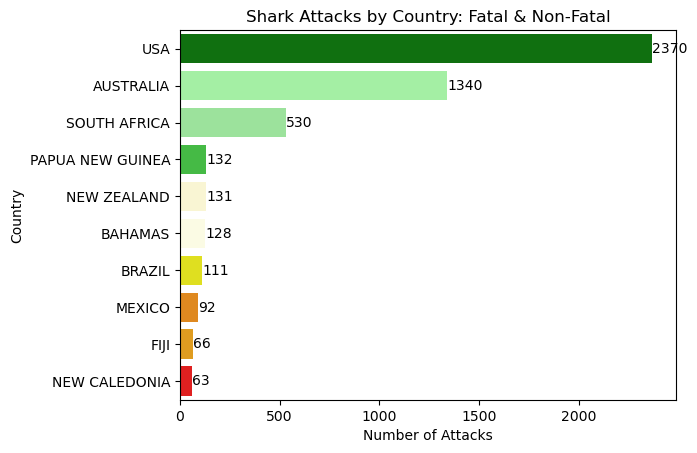

*****FATAL/NON FATAL ATTACKS FOR THE TOP N COUNTRIES *****




,country,fatal_y/n,count
1,AUSTRALIA,N,1037
3,AUSTRALIA,Y,303
5,BAHAMAS,N,113
9,BRAZIL,N,72
7,NEW ZEALAND,N,106
8,PAPUA NEW GUINEA,N,74
2,SOUTH AFRICA,N,421
6,SOUTH AFRICA,Y,109
0,USA,N,2169
4,USA,Y,201


*****TRENDS OF ATTACKES OVER YEARS *****


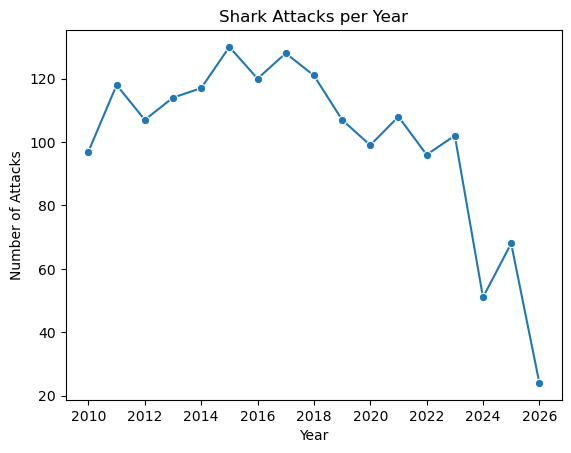

Axes(0.125,0.11;0.775x0.77)
*****TYPE OF ACTIVITIES DURING THE ATTACKS *****


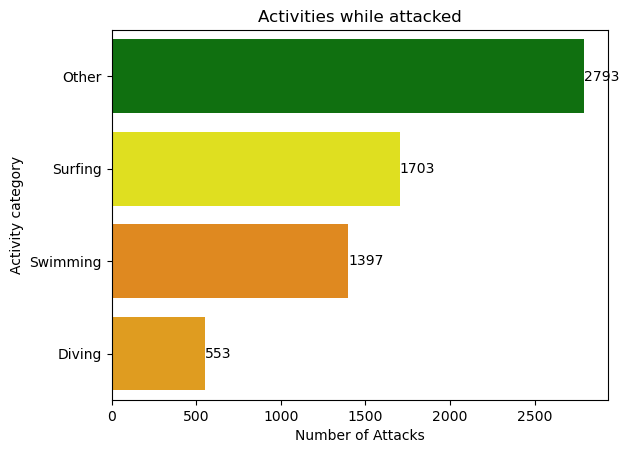

Axes(0.125,0.11;0.775x0.77)
None


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = shark_dataset = pd.read_excel("https://www.sharkattackfile.net/spreadsheets/GSAF5.xls")
#df = shark_dataset = pd.read_excel("GSAF5.xls") 
def rename_columns(df):
    """
    function N°1:
    remove white spaces (strip) and replace them by "_"

    """
    df1 = df.copy()
    df1.rename(columns={col : col.strip() for col in df1.columns}, inplace = True)
    df1.rename(columns={col : col.replace(" ", "_").lower() for col in df1.columns}, inplace = True)
    return df1

def delete_columns(df):
    """
    Function N°2
    
    delete irrelivent columns
    input: dataframe
    output: dataframe
    """
    df1 = df.copy()
    cols_to_delete = ["pdf", "Location", 'href formula', 'href', 'Case Number', 'Case Number.1','original order', 'Unnamed: 21', 'Unnamed: 22', "Species ","Source"]
      
    df1.drop(cols_to_delete, axis = 1, inplace = True)
    
    return df1
    
def clean_fatal_col(df):
    """
    function N°3:
    replaces values with Y/N
    
    """
    df1 = df.copy()
    df1["Fatal Y/N"] = df1["Fatal Y/N"].apply(lambda x : "N" if (str(x).strip().lower()[0] == "n" and len(str(x).strip()) != 3) else ("Y" if str(x).strip().lower().startswith("y") else str(x).strip().lower()))
    
    return df1

def clean_age_col(df):
    """
    function N°4:
    
    """
    df1 = df.copy()
    mapping_age = {"Middle age": 40, "young": 25, "Elderly" : 60, "Teen": 15, "teen": 15, '"middle-age"': 40,'"young"': 15 }
    df1["Age"] = df1.Age.apply(lambda x : str(x).strip().strip("?").strip("!").strip("+").strip("'s").strip("&"))
    df1["Age"] = df1.Age.replace(mapping_age)
                         
    return df1

#####################################################################################################################################   

def activity_col_anlaysis(df):
    df1 = df.copy()
    df1["activity_category"] = df1["Activity"].apply(
            lambda x: "Swimming" if any(word in str(x).lower() for word in ["swim", "bath", "float"]) else 
              ("Surfing" if any(word in str(x).lower() for word in ["surf", "board", "paddl"]) else
               "Diving" if "div" in str(x).lower() else "Other"))
                  
    return df1

def drop_rows(df):

    """
    This functions drops the irrelivant rows: 
    1: from column FATAL Y/N:
    "nan"=561, "unknown":71 , "f": 5, "m": 3, "2017": 1 ==>641/4953(N)+1493(Y) =10%
    
    """
    df1 = df.copy()
    df1 = df1[(df1["Fatal Y/N"] == "N") | (df1["Fatal Y/N"] == "Y")]

    return df1

    
def main_clean_function(df):
    """
    input: a copy of df: shark attacks
    
    groups all clean functions.

    output a cleaned df
    """
    df1 = df.copy()
    df1 = delete_columns(df1)
    df1 = clean_fatal_col(df1)
    df1 = clean_age_col(df1)
    df1 = activity_col_anlaysis(df1)
    df1 = drop_rows(df1)
    
    df1 = rename_columns(df1) #this function should be at the end of the execution list, as column names changed
    return df1 
##########################################################################################################"
def top_att_countries_table(df, top_n = 10):
    """
    Calculates the top countries with the highest nbr of attacke, together with the kind of attackes (Fatal/injury)
    input DF
    Output: Returns the top 5 countries with the highest number of shark attacks, indicating wether or not the attack was fatal
    def plot_top_n_countires( 
    """
    df1 = df.copy()
        
    #top_n_countries = pd.DataFrame(df1.groupby(["country", "fatal_y/n"])["fatal_y/n"].count().nlargest(top_n))
    #top_n_countries =pd.DataFrame(df1.groupby("country")["fatal_y/n"].count().nlargest(top_n))
    top_n_countries = df1.groupby(["country","fatal_y/n"])["fatal_y/n"].size().nlargest(10).reset_index(name = "count").sort_values(by="country")

    plt.show()
    return top_n_countries

    
def top_att_countries_plot(df, top_n = 10):
    
    """
    returns a plot: nbr of attacke per country/5top
    input: cleaned up dataframe
    Output: Returns the top 5 countries with the highest number of shark attacks,
    def plot_top_n_countires 

    """
    df1 = df.copy()
    #top_n_countries = pd.DataFrame(df1.groupby("country")["fatal_y/n"].count().nlargest(top_n))
    top_n_countries = df1.groupby("country")["fatal_y/n"].size().nlargest(10).reset_index(name = "count")
    
     #Plot settings:
    plt.title('Shark Attacks by Country: Fatal & Non-Fatal')
    plt.ylabel('Country')
    plt.xlabel('Number of Attacks')
    
    #plt colors
    my_colors =["green", "palegreen", "lightgreen", "limegreen", "lemonchiffon", "lightyellow", "yellow", "darkorange", "orange", "red"]
            
    #plot
    #attacks_by_country_plot = sns.barplot(y = 'country', x = "fatal_y/n", hue= "fatal_y/n", palette = my_colors, data = top_n_countries, legend=0)
    attacks_by_country_plot = sns.barplot(y = "country", x = "count", hue= "country", palette = my_colors, data = top_n_countries, legend=0)
    #set up legend directly on bars
    for i in range(top_n):
        attacks_by_country_plot.bar_label(attacks_by_country_plot.containers[i])
    plt.show()
    
    return attacks_by_country_plot
    
def attacks_per_year_plot(df, start_year = 2010):
    """
    Shows the variation of attacks over time. Drop empty rows for this exercise

    input: cleaned up dataframe
    output: line chart
    """
    df1 = df.copy()
    df1.dropna(subset = ["year"], inplace = True) #drop nan from "year column"
    df1["year"] = df1["year"].apply(int)
    df1 = df1[df1.year >= start_year]
    grouped_values = df1.groupby("year").size().reset_index(name = "count")
    
    time_plot = sns.lineplot(data=grouped_values, x='year', y ="count", marker="o")
    
     #Plot settings:
    time_plot.set_title("Shark Attacks per Year")
    time_plot.set_xlabel("Year")
    time_plot.set_ylabel("Number of Attacks")
    plt.show()
    
    return time_plot
    
def activity_categories_plot(df):

    """
     input: cleaned up dataframe
    
    """
    df1 = df.copy()
    grouped = df1.groupby("activity_category")
    grouped_categories = grouped.size().reset_index(name = "count").sort_values(by="count", ascending = False)
    
    #plot settings
   
    my_colors =["green", "yellow", "darkorange", "orange"]

    #PLOT:
    cat_plot = sns.barplot(x = "count", y = "activity_category", hue ="activity_category", data = grouped_categories, palette = my_colors, legend = False)
    
    plt.title('Activities while attacked')
    plt.ylabel('Activity category')
    plt.xlabel('Number of Attacks')
    
    #write the legends on every bar
    for i in range(len(grouped)):
        cat_plot.bar_label(cat_plot.containers[i])
    plt.show()
    
    return cat_plot

def generating_plots(df, start_year = 2010, top_country = 10):
    """
    input: cleaned up dataframe
    Gathers all the functions and execute them upon call in the following order:
    1. Generates the cleaned df
    2. Executes the plotting functions:  4 fucntions

    input: data frame, default variable top_coutries = 10, start_year for the attacks per year trend: default = 2010
    output: 4 polts

    """
    df1 = main_clean_function(df)
    
    print(50 * "=")
    print(f"[bold red]{5*'*'}TOP N COUNTRIES (HIGHEST NUMBER OF ATTACKS {5*'*'}[/bold red]")
    plot1 = top_att_countries_plot(df1, 10)
    #print(plot1)
    print(50 * "=")
    print(f"{5*'*'}FATAL/NON FATAL ATTACKS FOR THE TOP N COUNTRIES {5*'*'}")
    print()
    plot2 = top_att_countries_table(df1, 10)
    print()
    display(plot2)
    print(50 * "=")
    print(f"{5*'*'}TRENDS OF ATTACKES OVER YEARS {5*'*'}")
    plot3 = attacks_per_year_plot(df1, 2010)
    print(plot3)
    print(50 * "=")
    print(f"{5*'*'}TYPE OF ACTIVITIES DURING THE ATTACKS {5*'*'}")
    plot4 = activity_categories_plot(df1)
    print(plot4)
    

    
    
#df1=main_clean_function(df)
plots = generating_plots(df, start_year = 2010, top_country = 10)

#top_n_countries = df1.groupby("country")["fatal_y/n"].size().nlargest(10).reset_index(name = "count")
#print(top_n_countries)
#plots = top_att_countries_plot(df1, top_n = 10) #generating_plots(df)
print(plots)

##plots = top_att_countries_plot(df1, top_n = 10) #generating_plots(df)
#print(plots)

#year_plot = activity_categories_plot(df1)
#top_n_countries =pd.DataFrame(df1.groupby("country")["fatal_y/n"].count())
#top_n_countries
                              
#my_file = df1.to_excel("shark_attacks_cleaned.xlsx")
#plot_ = top_att_countries_plot(df, 10)
#display(plot_)
#top_count = top_att_countries(df)
#display(top_count)
#top10_overall = top_attack_countries(df1)
#top10_overall


#display(df1[["activity_category"]])
#df1.duplicated()
#display(df.select_dtypes('number'))
#display(df1.head())
#df.columns
#display(df1["Fatal Y/N"].value_counts())
#df1["Age"].unique()
#d#isplay(df1.isnull().sum())
#df1.info()
#display(df1.activity_category.unique())
#df1 = delete_columns(df)

#df2 = rename_columns(df2)
#df2 = delete_columns(df2)
#df.describe()
#df1.dtypes

#df.isna().sum()
#df.value_counts() #applies on column
#df.Activity.nunique()